# 1. Exploratory Data Analysis

Read-only analysis of the raw HDB resale transactions. No feature engineering — just understanding the data.

**Sections:**
1. Load & inspect raw data
2. Target variable analysis (resale_price)
3. Categorical feature distributions
4. Numerical feature analysis
5. Correlation analysis
6. Time series trends

In [2]:
%pip install pandas numpy matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

Matplotlib is building the font cache; this may take a moment.


## 1.1 Load & Inspect Raw Data

In [4]:
df = pd.read_csv("../data/raw/resale_transactions.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (692719, 11)


/var/folders/kz/x1bqw4g54k9bxv6zd2qlrp500000gn/T/ipykernel_26338/3383761502.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/resale_transactions.csv")


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,remaining_lease
0,2000-01,ANG MO KIO,3 ROOM,170,ANG MO KIO AVE 4,07 TO 09,69.0,Improved,1986,147000.0,NaN
1,2000-01,ANG MO KIO,3 ROOM,174,ANG MO KIO AVE 4,04 TO 06,61.0,Improved,1986,144000.0,NaN
2,2000-01,ANG MO KIO,3 ROOM,216,ANG MO KIO AVE 1,07 TO 09,73.0,New Generation,1976,159000.0,NaN
3,2000-01,ANG MO KIO,3 ROOM,215,ANG MO KIO AVE 1,07 TO 09,73.0,New Generation,1976,167000.0,NaN
4,2000-01,ANG MO KIO,3 ROOM,218,ANG MO KIO AVE 1,07 TO 09,67.0,New Generation,1976,163000.0,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692719 entries, 0 to 692718
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                692719 non-null  object 
 1   town                 692719 non-null  object 
 2   flat_type            692719 non-null  object 
 3   block                692719 non-null  object 
 4   street_name          692719 non-null  object 
 5   storey_range         692719 non-null  object 
 6   floor_area_sqm       692719 non-null  float64
 7   flat_model           692719 non-null  object 
 8   lease_commence_date  692719 non-null  int64  
 9   resale_price         692719 non-null  float64
 10  remaining_lease      270865 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 58.1+ MB


In [6]:
print("Null counts:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Null counts:
month                       0
town                        0
flat_type                   0
block                       0
street_name                 0
storey_range                0
floor_area_sqm              0
flat_model                  0
lease_commence_date         0
resale_price                0
remaining_lease        421854
dtype: int64

Duplicate rows: 1101


In [7]:
df.describe()

,floor_area_sqm,lease_commence_date,resale_price
count,692719.000000,692719.000000,6.927190e+05
mean,96.616384,1991.146295,3.874924e+05
std,24.955120,11.976277,1.859261e+05
min,28.000000,1966.000000,2.800000e+04
25%,74.000000,1983.000000,2.500000e+05
50%,95.000000,1988.000000,3.565000e+05
75%,113.000000,1999.000000,4.830000e+05
max,366.700000,2022.000000,1.728000e+06


In [8]:
# Unique values for categorical columns
for col in ['town', 'flat_type', 'flat_model', 'storey_range']:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(df[col].value_counts().head(10))


town (26 unique):
town
WOODLANDS        59676
TAMPINES         53255
JURONG WEST      50903
YISHUN           45750
BEDOK            42016
HOUGANG          37504
SENGKANG         36330
ANG MO KIO       33642
CHOA CHU KANG    31915
BUKIT BATOK      31017
Name: count, dtype: int64

flat_type (7 unique):
flat_type
4 ROOM              276731
3 ROOM              195715
5 ROOM              159419
EXECUTIVE            50747
2 ROOM                9339
1 ROOM                 496
MULTI-GENERATION       272
Name: count, dtype: int64

flat_model (21 unique):
flat_model
Model A              215731
Improved             180726
New Generation       116096
Premium Apartment     51980
Simplified            36276
Apartment             27193
Standard              26437
Maisonette            18695
Model A2              10695
DBSS                   4014
Name: count, dtype: int64

storey_range (25 unique):
storey_range
04 TO 06    169162
07 TO 09    151715
01 TO 03    134641
10 TO 12    130287
13 TO 15     5

## 1.2 Target Variable — Resale Price

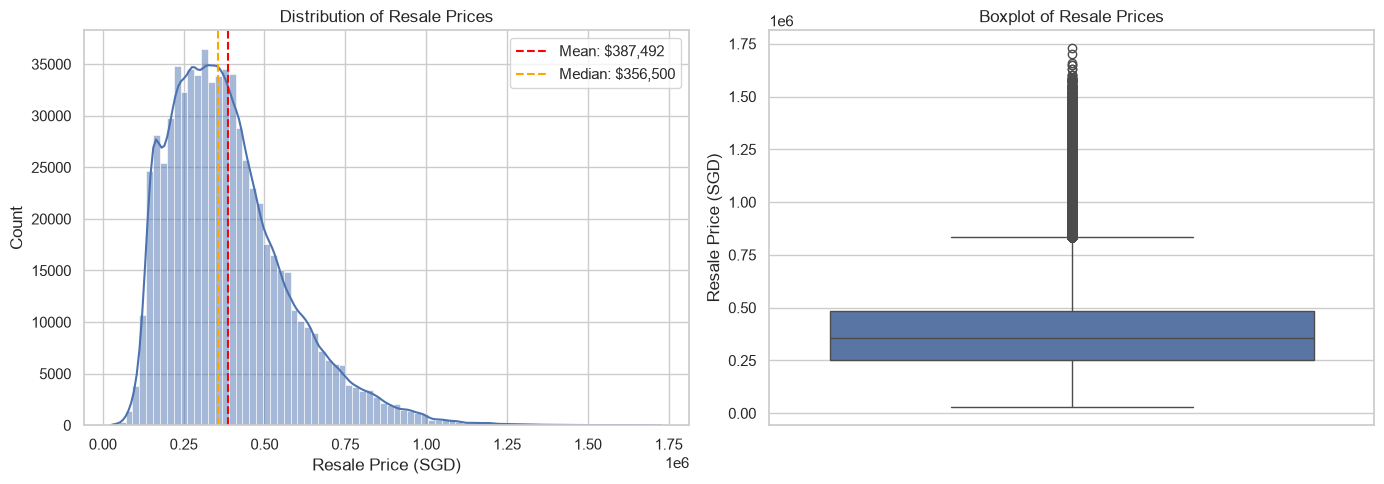

Mean:   $387,492
Median: $356,500
Std:    $185,926
Min:    $28,000
Max:    $1,728,000
Skew:   1.11


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["resale_price"], bins=80, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Resale Prices")
axes[0].set_xlabel("Resale Price (SGD)")
axes[0].axvline(df["resale_price"].mean(), color="red", linestyle="--", label=f'Mean: ${df["resale_price"].mean():,.0f}')
axes[0].axvline(df["resale_price"].median(), color="orange", linestyle="--", label=f'Median: ${df["resale_price"].median():,.0f}')
axes[0].legend()

sns.boxplot(y=df["resale_price"], ax=axes[1])
axes[1].set_title("Boxplot of Resale Prices")
axes[1].set_ylabel("Resale Price (SGD)")

plt.tight_layout()
plt.show()

print(f"Mean:   ${df['resale_price'].mean():,.0f}")
print(f"Median: ${df['resale_price'].median():,.0f}")
print(f"Std:    ${df['resale_price'].std():,.0f}")
print(f"Min:    ${df['resale_price'].min():,.0f}")
print(f"Max:    ${df['resale_price'].max():,.0f}")
print(f"Skew:   {df['resale_price'].skew():.2f}")

## 1.3 Categorical Feature Distributions

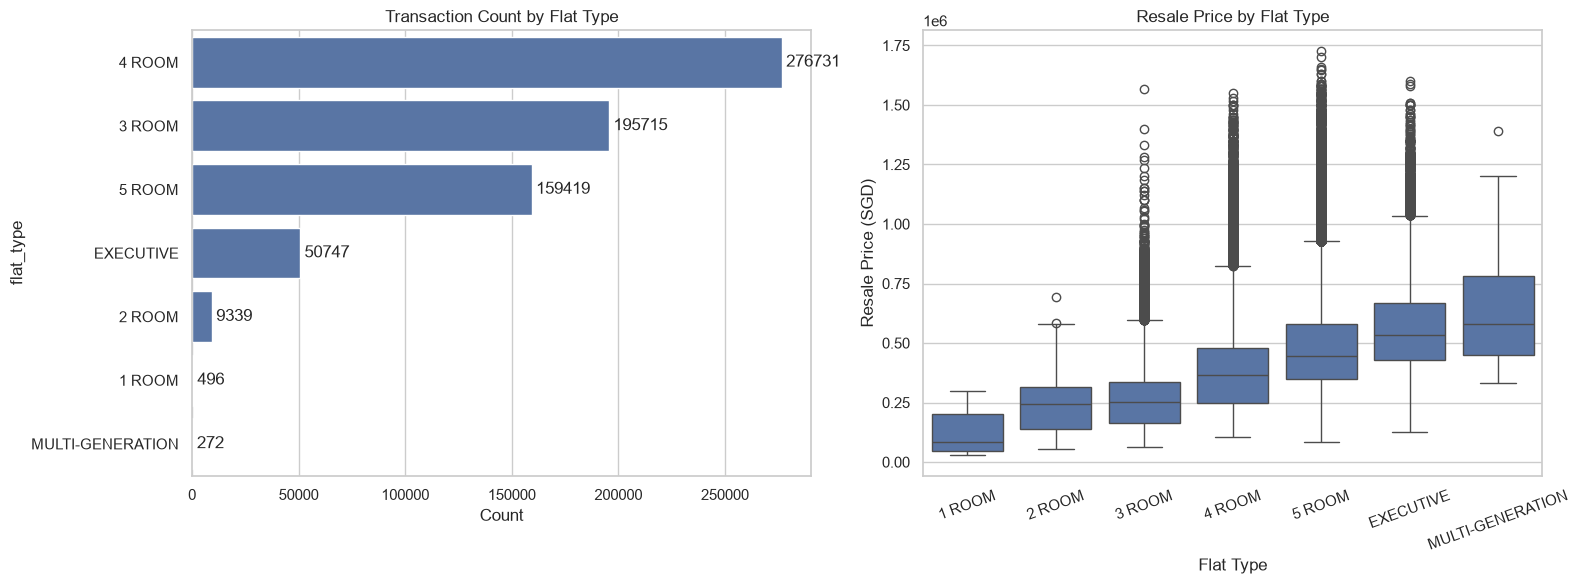

In [10]:
# Flat type frequency
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

freq = df["flat_type"].value_counts()
sns.barplot(x=freq.values, y=freq.index, ax=axes[0], orient="h")
axes[0].set_title("Transaction Count by Flat Type")
axes[0].set_xlabel("Count")
axes[0].bar_label(axes[0].containers[0], padding=3)

sns.boxplot(data=df, x="flat_type", y="resale_price", ax=axes[1],
            order=df.groupby("flat_type")["resale_price"].median().sort_values().index)
axes[1].set_title("Resale Price by Flat Type")
axes[1].set_xlabel("Flat Type")
axes[1].set_ylabel("Resale Price (SGD)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

/var/folders/kz/x1bqw4g54k9bxv6zd2qlrp500000gn/T/ipykernel_26338/2675685249.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_towns.values, y=top_towns.index, ax=axes[0], palette="Reds_r")
/var/folders/kz/x1bqw4g54k9bxv6zd2qlrp500000gn/T/ipykernel_26338/2675685249.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_towns.values, y=bottom_towns.index, ax=axes[1], palette="Blues_r")


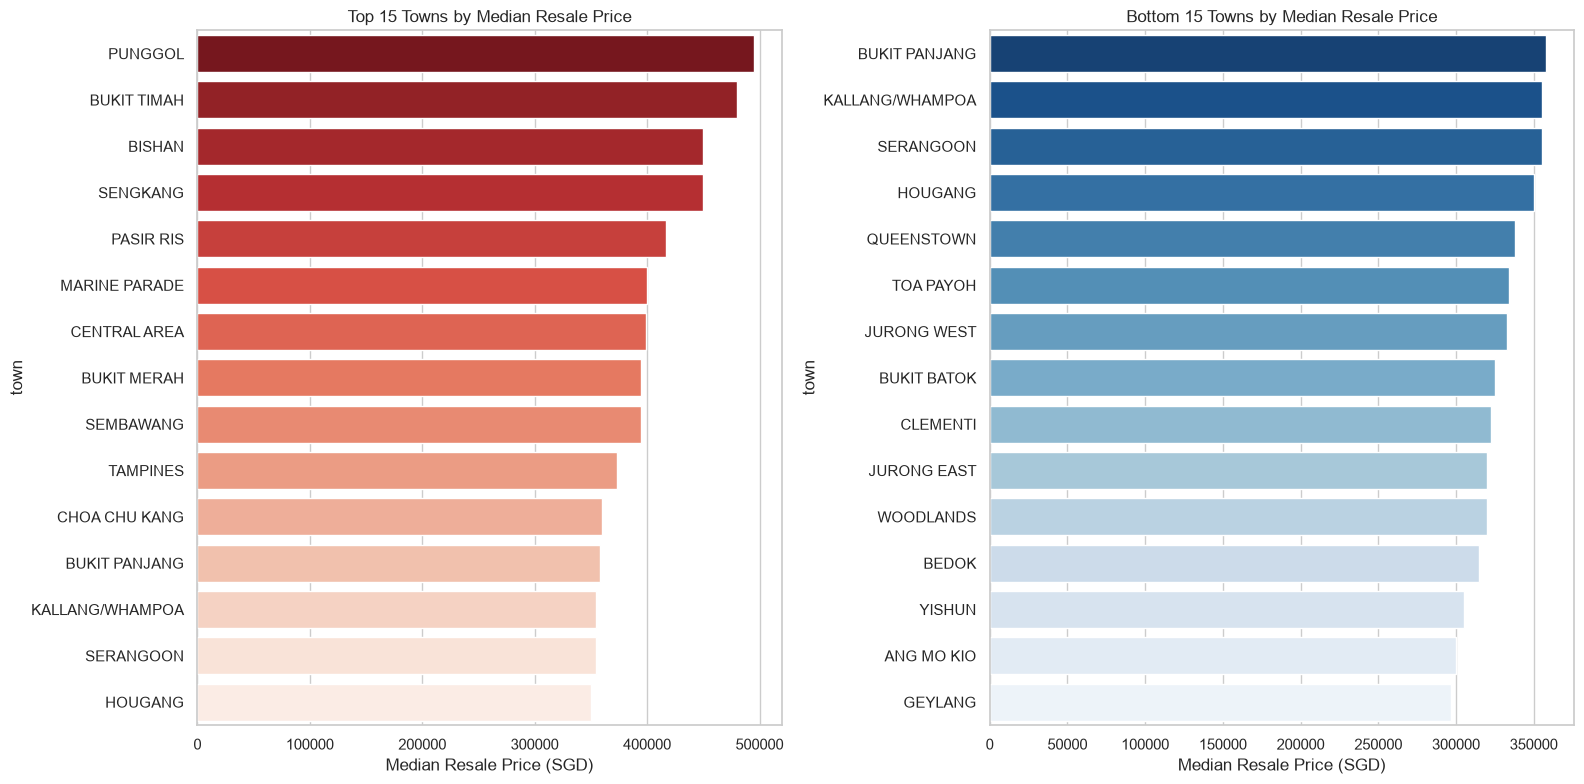

In [11]:
# Resale price by town — top 15 and bottom 15 by median price
town_median = df.groupby("town")["resale_price"].median().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_towns = town_median.head(15)
sns.barplot(x=top_towns.values, y=top_towns.index, ax=axes[0], palette="Reds_r")
axes[0].set_title("Top 15 Towns by Median Resale Price")
axes[0].set_xlabel("Median Resale Price (SGD)")

bottom_towns = town_median.tail(15)
sns.barplot(x=bottom_towns.values, y=bottom_towns.index, ax=axes[1], palette="Blues_r")
axes[1].set_title("Bottom 15 Towns by Median Resale Price")
axes[1].set_xlabel("Median Resale Price (SGD)")

plt.tight_layout()
plt.show()

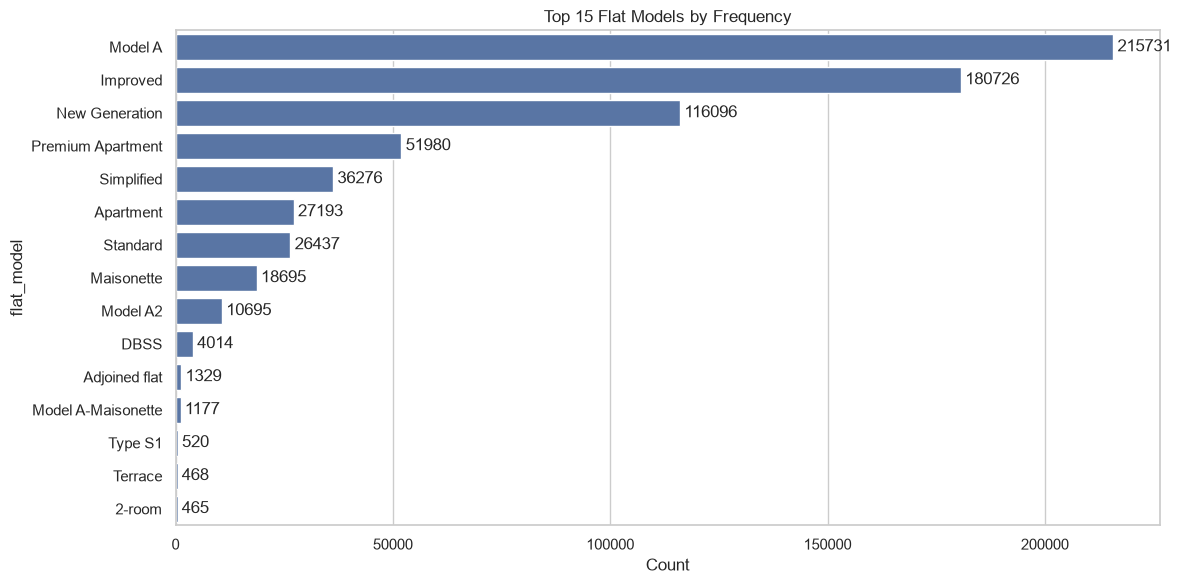

In [12]:
# Flat model distribution (top 15)
model_counts = df["flat_model"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=model_counts.values, y=model_counts.index, ax=ax)
ax.set_title("Top 15 Flat Models by Frequency")
ax.set_xlabel("Count")
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()

## 1.4 Numerical Feature Analysis

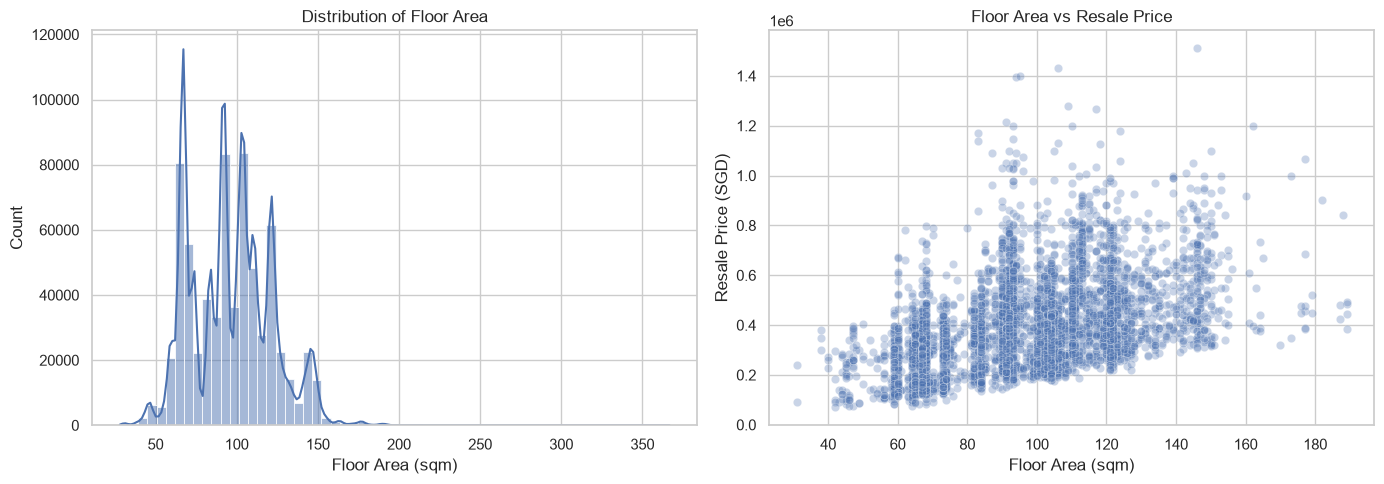

In [13]:
# Floor area distribution and its relationship with resale price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["floor_area_sqm"], bins=60, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Floor Area")
axes[0].set_xlabel("Floor Area (sqm)")

sns.scatterplot(data=df.sample(5000, random_state=42), x="floor_area_sqm", y="resale_price",
                alpha=0.3, ax=axes[1])
axes[1].set_title("Floor Area vs Resale Price")
axes[1].set_xlabel("Floor Area (sqm)")
axes[1].set_ylabel("Resale Price (SGD)")

plt.tight_layout()
plt.show()

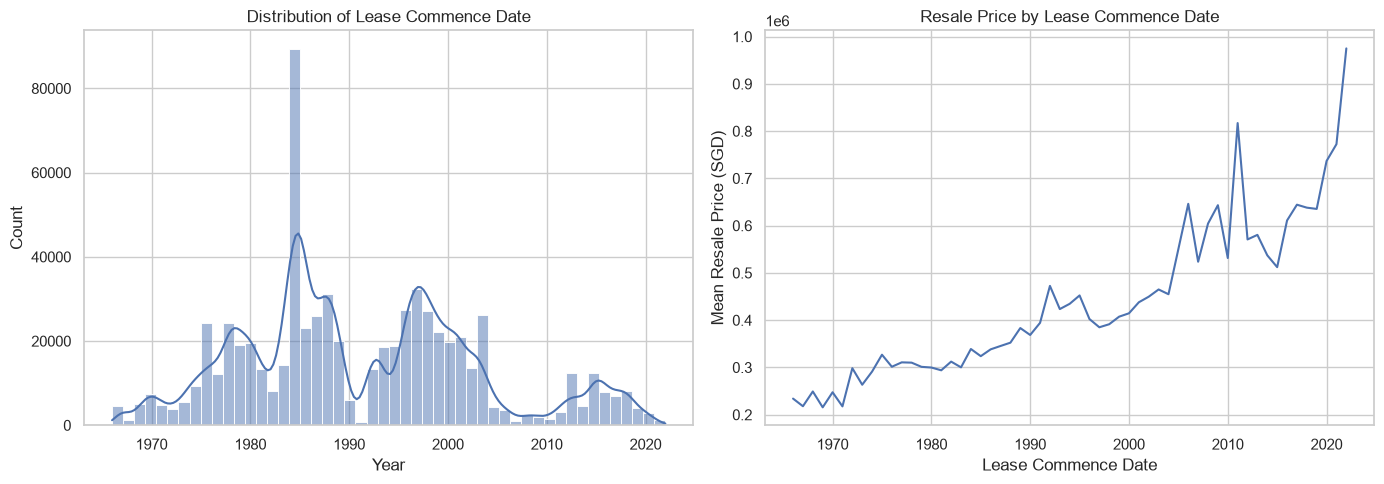

In [14]:
# Lease commence date vs resale price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["lease_commence_date"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Lease Commence Date")
axes[0].set_xlabel("Year")

sns.lineplot(data=df, x="lease_commence_date", y="resale_price", errorbar=None, ax=axes[1])
axes[1].set_title("Resale Price by Lease Commence Date")
axes[1].set_xlabel("Lease Commence Date")
axes[1].set_ylabel("Mean Resale Price (SGD)")

plt.tight_layout()
plt.show()

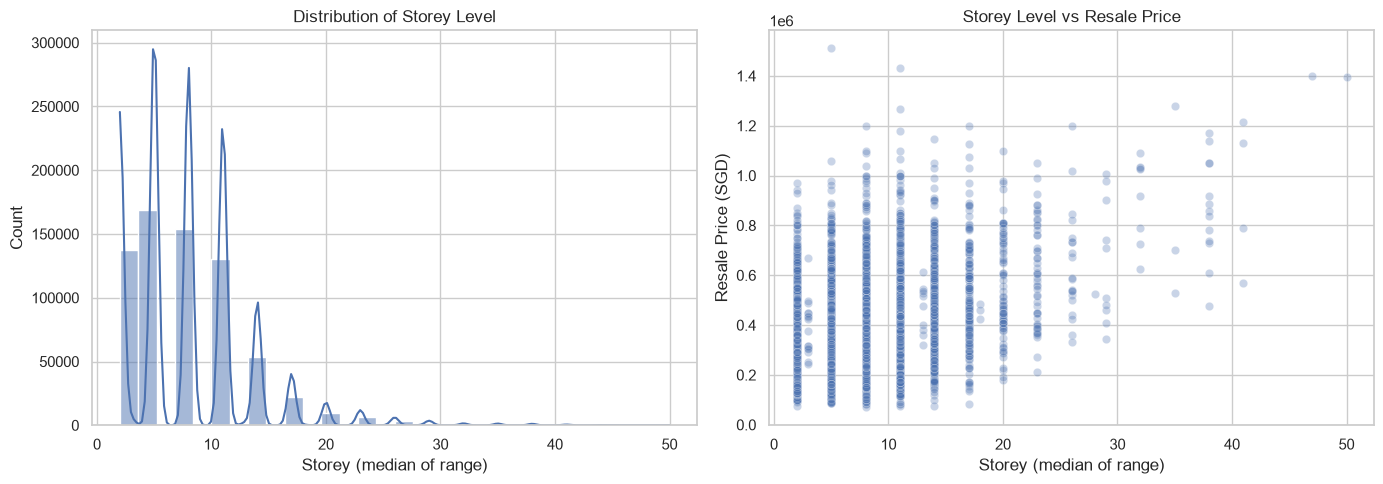

In [15]:
# Storey range — parse to numeric median for visualization
def storey_to_median(s):
    try:
        parts = s.split(" TO ")
        return (int(parts[0]) + int(parts[1])) / 2
    except (ValueError, IndexError):
        return np.nan

df["storey_median"] = df["storey_range"].apply(storey_to_median)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["storey_median"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Storey Level")
axes[0].set_xlabel("Storey (median of range)")

sns.scatterplot(data=df.sample(5000, random_state=42), x="storey_median", y="resale_price",
                alpha=0.3, ax=axes[1])
axes[1].set_title("Storey Level vs Resale Price")
axes[1].set_xlabel("Storey (median of range)")
axes[1].set_ylabel("Resale Price (SGD)")

plt.tight_layout()
plt.show()

## 1.5 Correlation Analysis

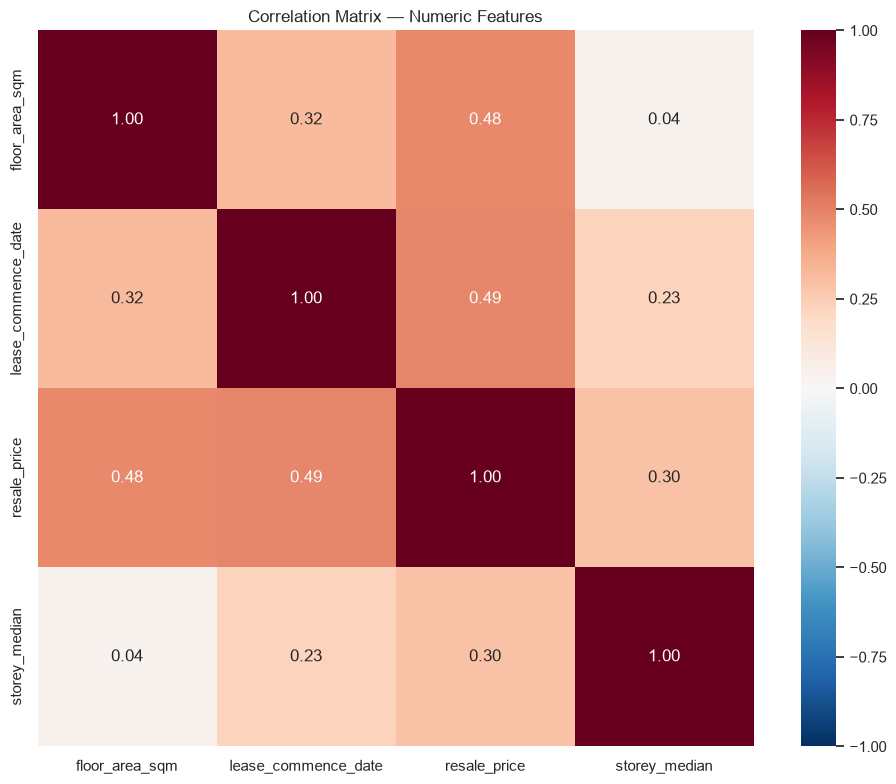

In [16]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Add storey_median if not already numeric
if "storey_median" not in numeric_cols:
    numeric_cols.append("storey_median")

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

In [17]:
# Correlation with target variable
target_corr = corr["resale_price"].drop("resale_price").sort_values(ascending=False)
print("Correlation with resale_price:")
print(target_corr)

Correlation with resale_price:
lease_commence_date    0.486836
floor_area_sqm         0.478517
storey_median          0.295925
Name: resale_price, dtype: float64


## 1.6 Time Series Trends

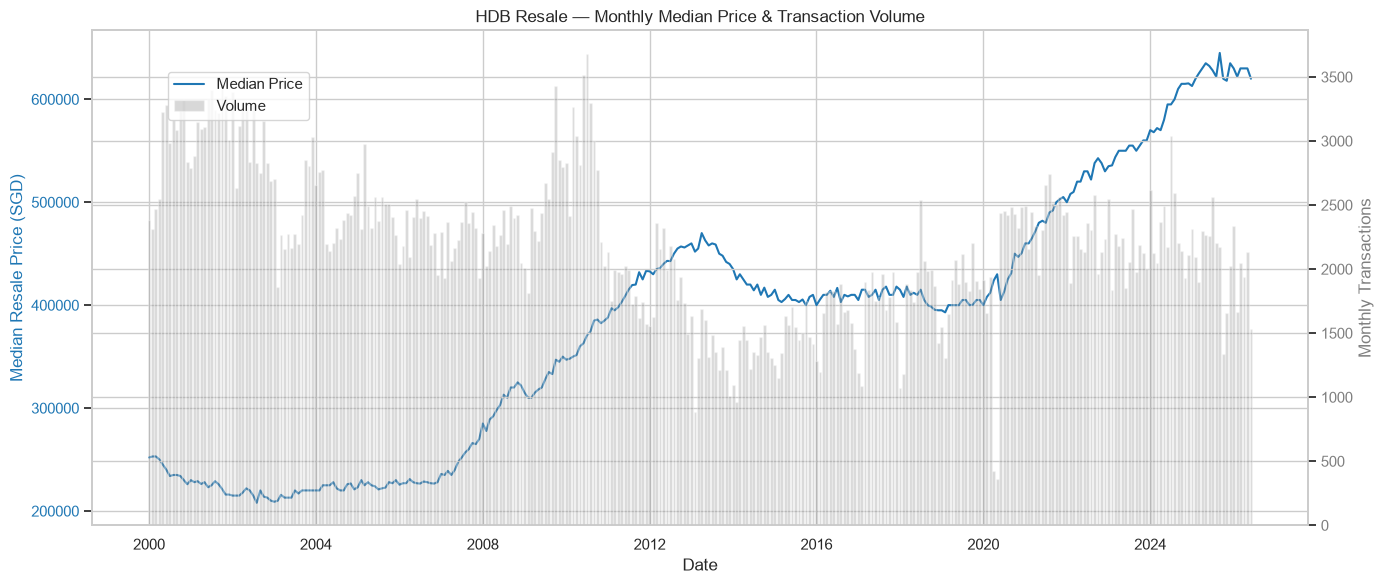

In [18]:
# Monthly median price and transaction volume over time
df["month_dt"] = pd.to_datetime(df["month"], format="%Y-%m")

monthly = df.groupby("month_dt").agg(
    median_price=("resale_price", "median"),
    mean_price=("resale_price", "mean"),
    count=("resale_price", "count")
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = "tab:blue"
ax1.plot(monthly["month_dt"], monthly["median_price"], color=color1, linewidth=1.5, label="Median Price")
ax1.set_xlabel("Date")
ax1.set_ylabel("Median Resale Price (SGD)", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
color2 = "tab:gray"
ax2.bar(monthly["month_dt"], monthly["count"], alpha=0.3, color=color2, width=25, label="Volume")
ax2.set_ylabel("Monthly Transactions", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

ax1.set_title("HDB Resale — Monthly Median Price & Transaction Volume")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

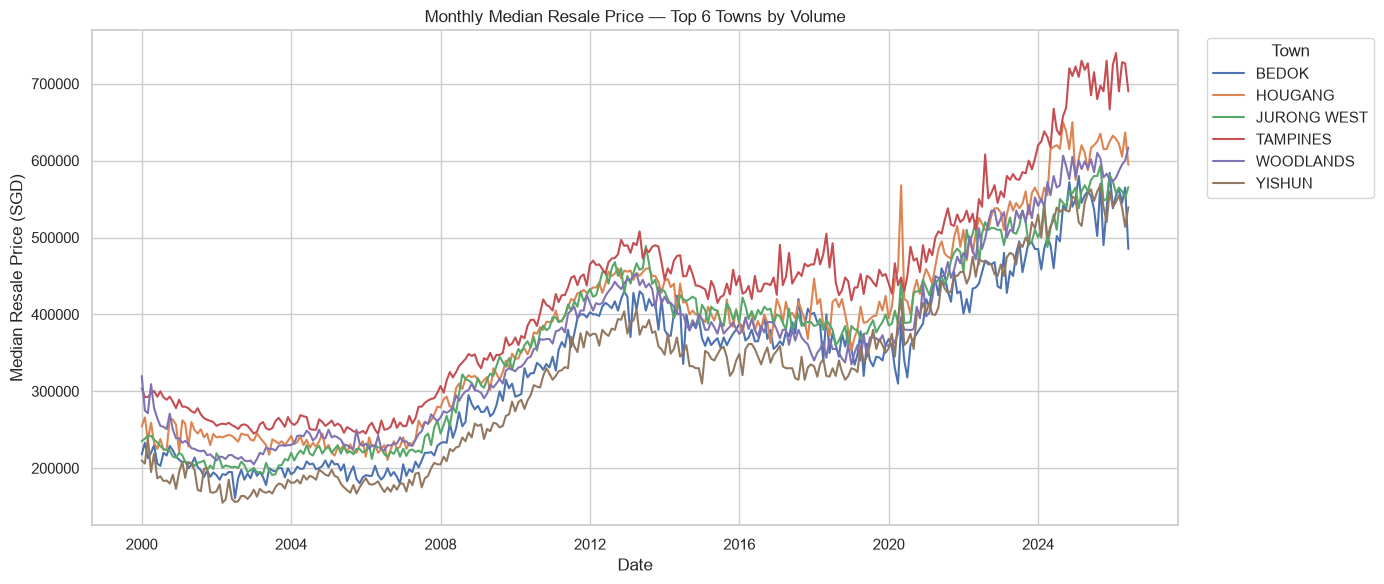

In [19]:
# Price trends by town (top 6 by transaction volume)
top_towns = df["town"].value_counts().head(6).index.tolist()
df_top = df[df["town"].isin(top_towns)]

town_monthly = df_top.groupby(["month_dt", "town"])["resale_price"].median().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=town_monthly, x="month_dt", y="resale_price", hue="town", ax=ax)
ax.set_title("Monthly Median Resale Price — Top 6 Towns by Volume")
ax.set_xlabel("Date")
ax.set_ylabel("Median Resale Price (SGD)")
ax.legend(title="Town", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

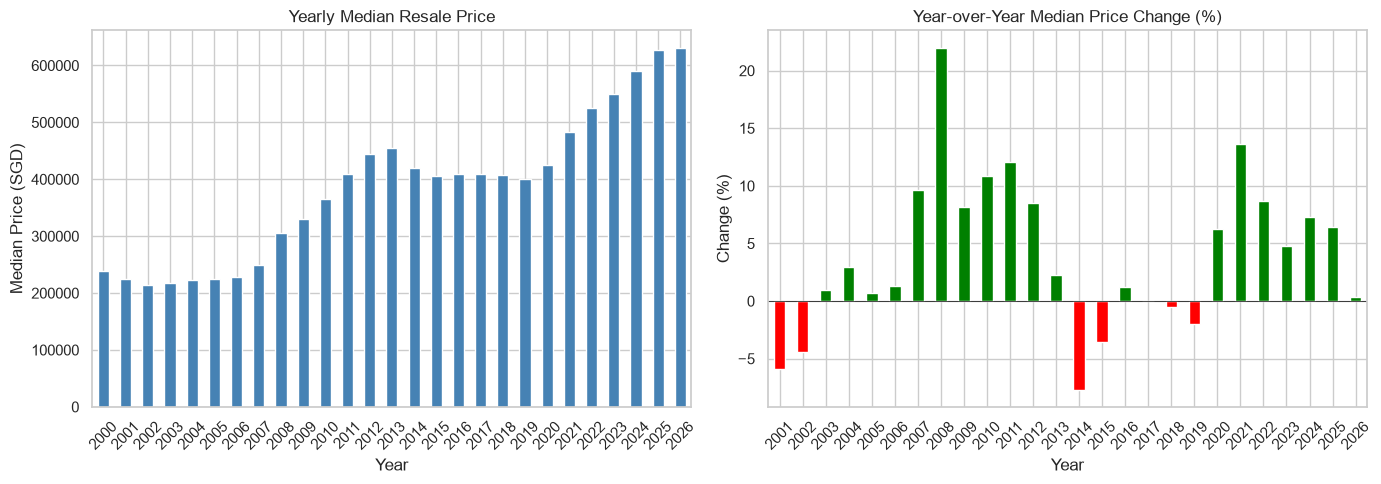

In [20]:
# Year-over-year median price change
yearly = df.groupby(df["month_dt"].dt.year)["resale_price"].median()
yoy_change = yearly.pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yearly.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Yearly Median Resale Price")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Median Price (SGD)")
axes[0].tick_params(axis="x", rotation=45)

yoy_change.dropna().plot(kind="bar", ax=axes[1], color=["green" if v > 0 else "red" for v in yoy_change.dropna()])
axes[1].set_title("Year-over-Year Median Price Change (%)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Change (%)")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 1.7 Key Takeaways

Observations to carry into feature engineering and modeling:

1. **Resale price is right-skewed** — mean > median, long right tail. Consider whether log-transform of target helps model performance.
2. **Floor area is the strongest linear predictor** — strong positive correlation with resale price.
3. **Newer leases command higher prices** — lease_commence_date positively correlated with price (longer remaining lease = more value).
4. **Higher floors = higher prices** — storey level positively correlated with resale price.
5. **Town matters significantly** — central/mature towns (Bukit Timah, Central Area, Queenstown) have much higher median prices than non-mature towns.
6. **Temporal trends are non-stationary** — prices rose steadily 2000-2013, dipped 2014-2017, then surged post-COVID 2020-2023. This reinforces the need for walk-forward validation, not random K-fold.
7. **Check remaining_lease nulls** — the 2000-2012 dataset may lack this column. Will need to compute from lease_commence_date in feature engineering.

Next step: `2_feature_engineering.ipynb`